# Examples

## Fisher’s iris dataset

Text(0.5, 0, 'Petal Length')

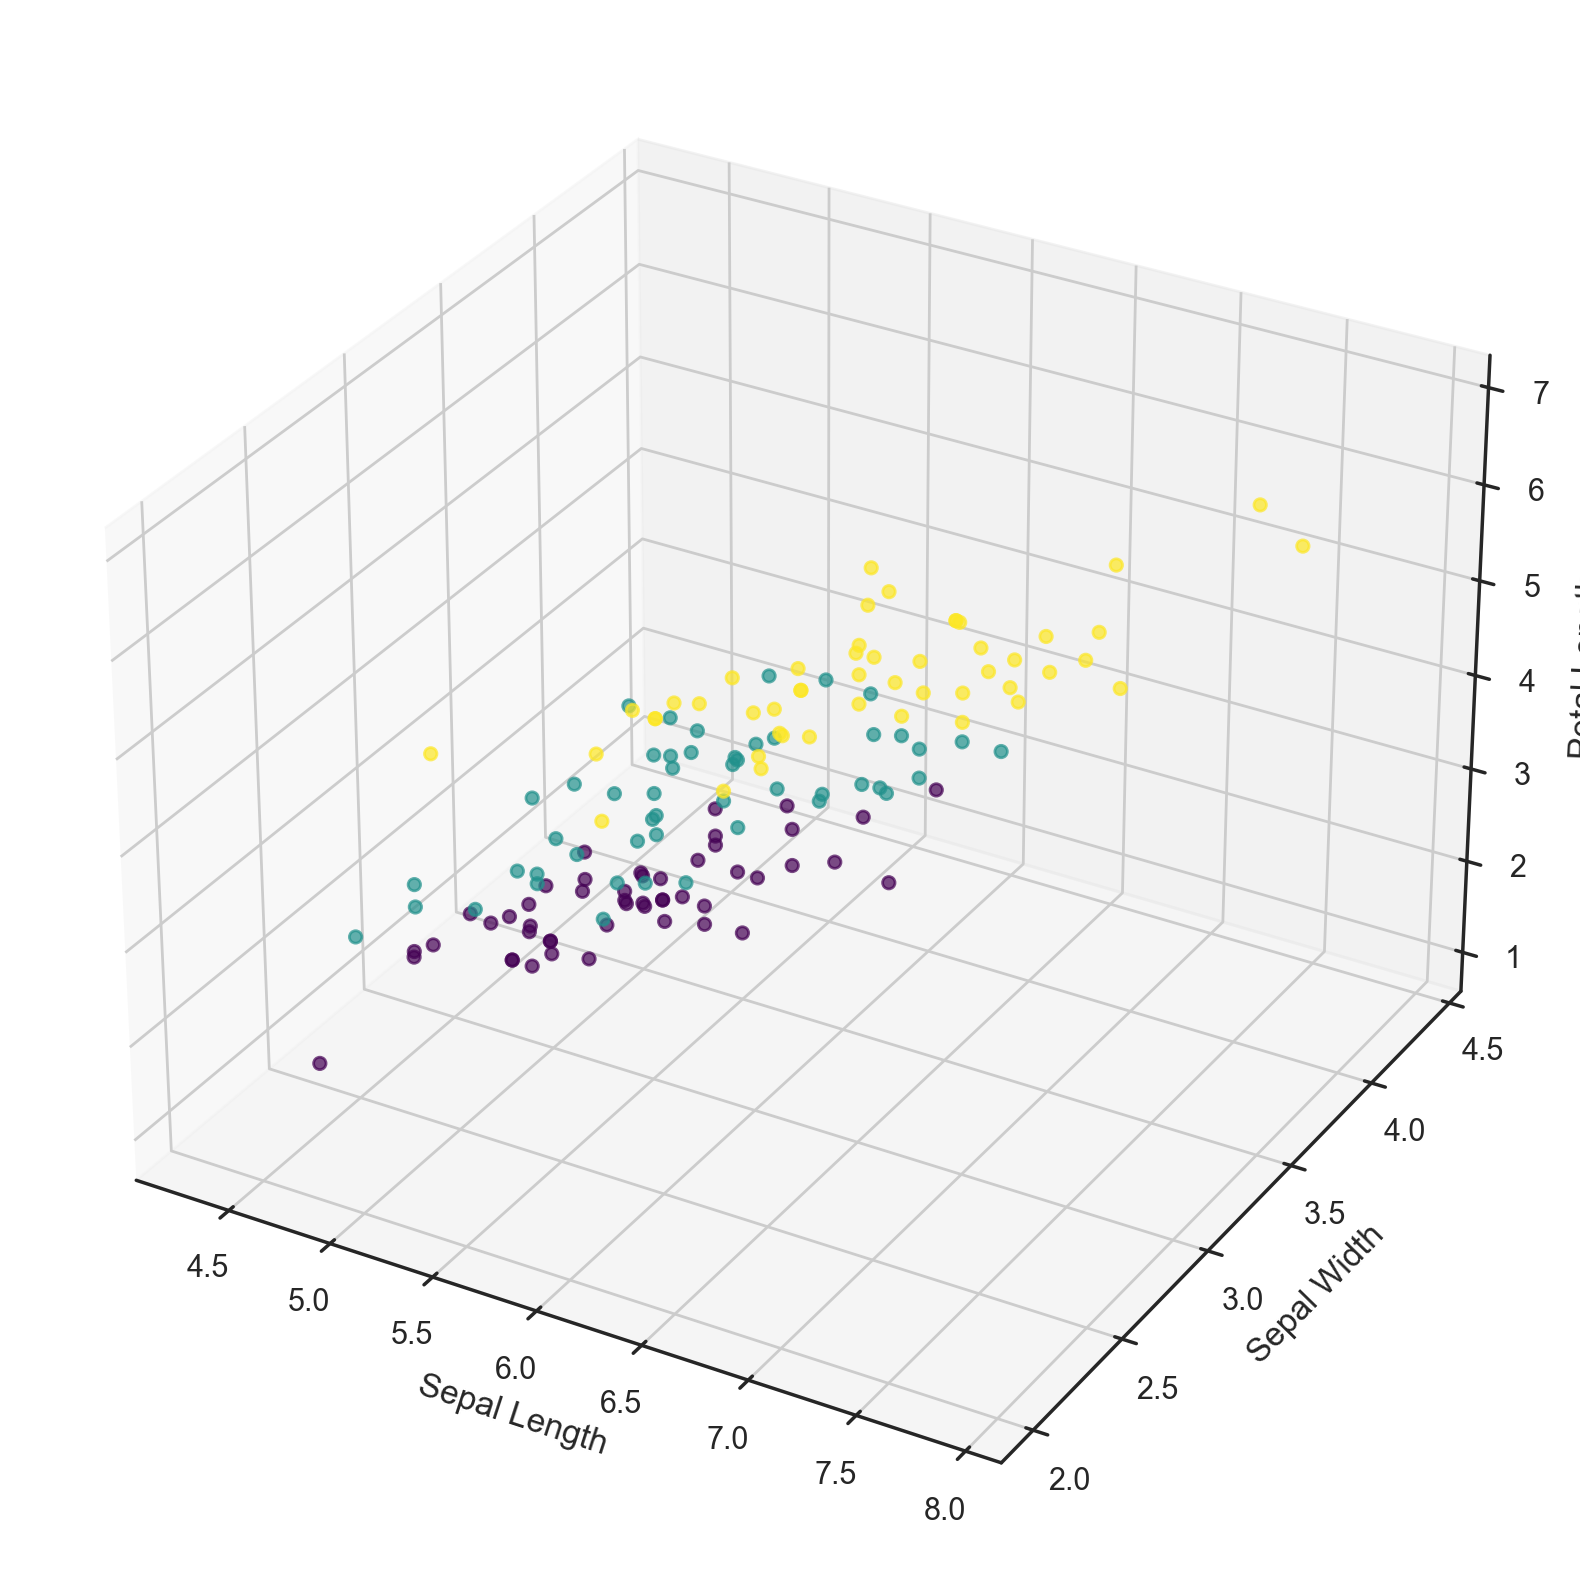

In [2]:
# Let’s start by uploading all of the essential modules and try out the iris example
#  from the scikit-learn documentation.

import numpy as np
import pandas as pd
from sklearn import datasets, decomposition

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="white")
from mpl_toolkits.mplot3d import Axes3D
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

# load the iris dataset
iris = datasets.load_iris()
X = iris.data
y = iris.target

# plot the dataset in 3d ignoring petal width
fig = plt.figure(figsize=(10,10))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(X[:, 0], X[:, 1], X[:, 2],  
           c=y, cmap='viridis', alpha=0.7)
ax.set_xlabel('Sepal Length')
ax.set_ylabel('Sepal Width')
ax.set_zlabel('Petal Length')

Now let’s see how PCA will improve the results of a simple model that is not able to correctly fit all of the training data:

In [4]:
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

# Train, test splits

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

# decision tree with depth 2
clf = DecisionTreeClassifier(max_depth=2, random_state=42)
clf.fit(X_train, y_train)
predicts = clf.predict_proba(X_test)
# print(predicts)
print("Accuracy: {:.5f}".format(accuracy_score(y_test, predicts.argmax(axis=1))))

Accuracy: 0.88889


Not quite. It's the probability that **the model assigns to each possible class**, **before knowing the true answer**.

Let's use an example.

Suppose you're predicting whether an email is spam.

The true label (`y_test`) for one email is:

```python
1   # Spam
```

The model predicts:

```python
clf.predict_proba(X_test)
```

returns

```python
[[0.30, 0.70]]
```

This means the model is saying:

* **30% chance** this email is **not spam (class 0)**
* **70% chance** this email is **spam (class 1)**

The model will therefore predict:

```python
clf.predict(X_test)
```

returns

```python
[1]
```

because 70% is larger than 30%.

---

Now compare that prediction to the actual label:

| Actual (`y_test`) | Predicted | Correct? |
| ----------------- | --------- | -------- |
| 1                 | 1         | ✅ Yes    |

In this case, the model was correct.

---

Now imagine another sample:

Actual label:

```python
0
```

Model says:

```python
[[0.10, 0.90]]
```

The model is **90% confident** the sample belongs to class 1.

So it predicts:

```python
1
```

But the true label is actually `0`.

| Actual | Predicted | Correct? |
| ------ | --------- | -------- |
| 0      | 1         | ❌ No     |

Even though the model gave **90% probability**, it was wrong.

---

### So what does `predict_proba()` mean?

It **does not** mean:

> "There is a 90% chance my prediction is correct."

It means:

> "Based on what I learned from the training data, I estimate there's a 90% probability this sample belongs to class 1."

Whether that estimate is actually correct is determined only by comparing it to the true label (`y_test`).

Think of it like a weather forecast:

* Weather app: "70% chance of rain."
* It either rains or it doesn't.

The **70%** is the model's estimate **before** the outcome is known—not a guarantee that the forecast itself is correct. The same idea applies to `predict_proba()`.


### Let’s try this again, but, this time, let’s reduce the dimensionality to 2 dimensions:

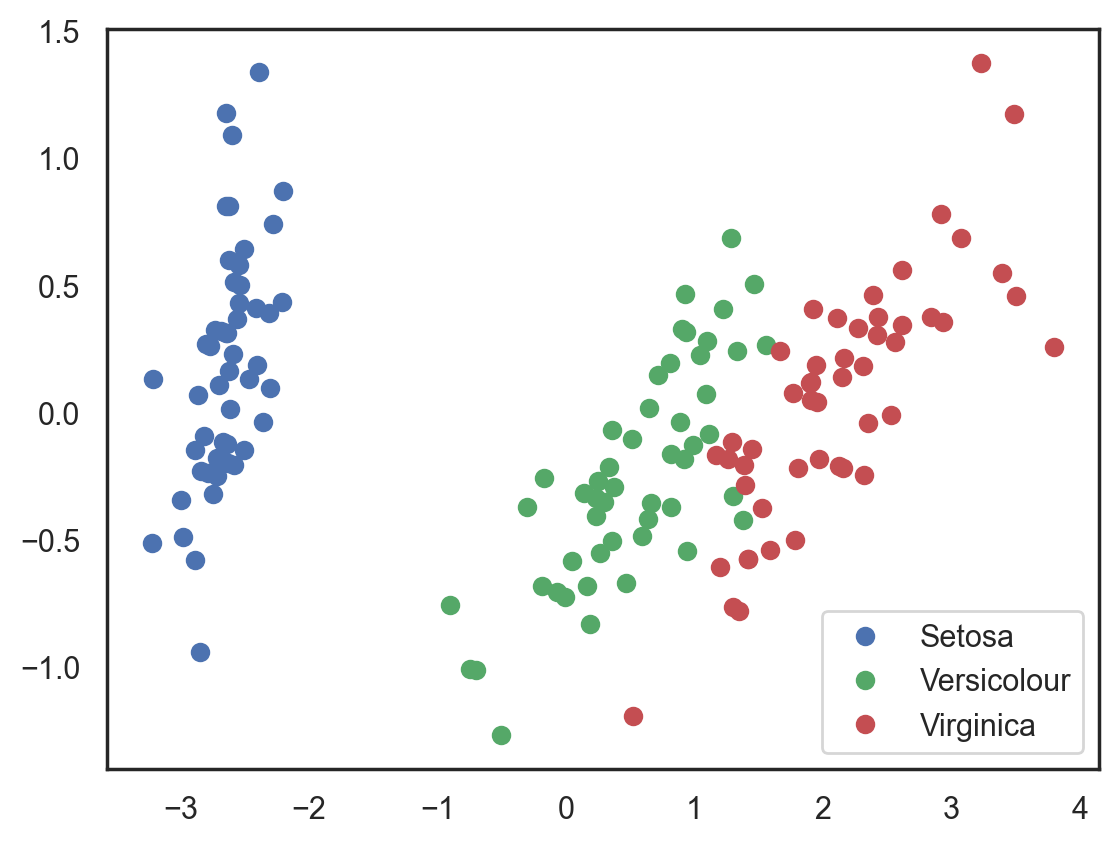

In [6]:
# Using PCA from sklearn pca

pca = decomposition.PCA(n_components=2)
X_centered = X - X.mean(axis=0)
pca.fit(X_centered)
X_pca = pca.transform(X_centered)

# X_pca

# Plotting the results of PCA
plt.plot(X_pca[y == 0, 0], X_pca[y == 0, 1], "bo", label="Setosa")
plt.plot(X_pca[y == 1, 0], X_pca[y == 1, 1], "go", label="Versicolour")
plt.plot(X_pca[y == 2, 0], X_pca[y == 2, 1], "ro", label="Virginica")
plt.legend(loc=0);

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X_pca, y, stratify=y, random_state=42
)
clf = DecisionTreeClassifier(max_depth=2, random_state=42)
clf.fit(X_train, y_train)
predicts = clf.predict_proba(X_test)
print("Accuracy: {:.5f}".format(accuracy_score(y_test, predicts.argmax(axis=1))))

Accuracy: 0.89474
